## CMPE-257, Machine Learning, Summer 2025
## Week 4: Overfitting, Regularization, Validation

In this workbook, you will be gaining experience on the practice of ML by experimenting with:

- subset selection methods
- regularization methods
- applying cross-validation 

In [ ]:
# YOUR NAME: Quoc Dung Lam

In [2]:
# loads required modules
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from itertools import combinations
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

[    idx   p0    p1       p2        p3        p4        p5        p6        p7  \
 0 -0.99  1.0 -0.99  0.97015 -0.940747  0.902233 -0.855180  0.800292 -0.738382   
 1 -0.25  1.0 -0.25 -0.40625  0.335938  0.157715 -0.339722  0.024277  0.279919   
 2 -0.12  1.0 -0.12 -0.47840  0.175680  0.321907 -0.210076 -0.222039  0.229548   
 3  0.88  1.0  0.88  0.66160  0.383680  0.094667 -0.156991 -0.332168 -0.408294   
 4  0.99  1.0  0.99  0.97015  0.940747  0.902233  0.855180  0.800292  0.738382   
 
           f         y  
 0 -0.175359 -0.116828  
 1  0.177344  0.302736  
 2  0.064000  0.033882  
 3  0.082000  0.037095  
 4  0.369389  0.255630  ,
          idx   p0        p1        p2        p3        p4        p5        p6  \
 0  -1.000000  1.0 -1.000000  1.000000 -1.000000  1.000000 -1.000000  1.000000   
 1  -0.979798  1.0 -0.979798  0.940006 -0.881828  0.807019 -0.717825  0.616911   
 2  -0.959596  1.0 -0.959596  0.881237 -0.769655  0.631548 -0.475132  0.309590   
 3  -0.939394  1.0 -0.93939

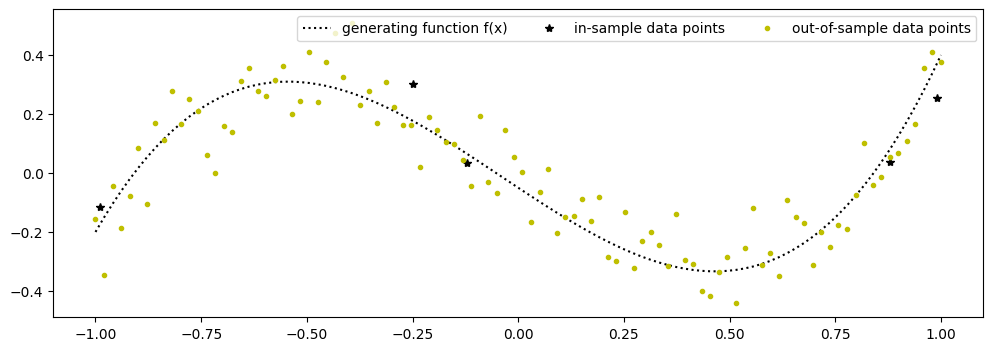

In [ ]:
# Loads and plots the dataset "w4_data.pkl" to be used in Parts 1 and 2
# The dataset is given in two dataframes data[0] and data[1] corresponding to the in-sample set (5 data samples)
# and out-of-sample set (100 data samples), respectively. Each dataframe contains 11 columns: a real-valued index  
# (idx), eight predictors (p0,p1,...'p7), the noisless target (f), and the noisy target/observations (y)

with open("w4_data.pkl", "rb") as file:
    data = pickle.load(file)

fig, ax = plt.subplots(1,1,figsize=(12,4))
ax.plot(data[1]['idx'].values,data[1]['f'].values,':k',label='generating function f(x)')
ax.plot(data[0]['idx'].values,data[0]['y'].values,'*k',label='in-sample data points')
ax.plot(data[1]['idx'].values,data[1]['y'].values,'.y',label='out-of-sample data points')
ax.legend(ncol=3)
plt.show()

In [5]:
# The following function is used to conduct linear regressions by using either the LinearRegression, Ridge,
# or Lasso classes in scikit learn. It admits the following input parmeters:
# datasets: a two element array of dataframes containing the in-sample and out-of-sample data sets
# variables: a list with the column names (from dataset dataframes) to be used as preditors in the regression
# regtype: the regression algorithm to be used (i.e. 'linear', 'ridge' or 'lasso')
# alpha (lambda): the shrinkage factor (only used in 'ridge' and 'lasso'), if zero then 'linear' is used
# verbose: a boolean flag to display the obtained coefficients, regression errors and R2 score
# plot: a boolean flag to plot the data and the resulting model curve (out-of-sample predictions)

def do_regression(datasets,variables,regtype='linear',alpha=0.0,verbose=False,plot=False):
    result = {}
    in_X = datasets[0][variables].to_numpy()
    in_Y = datasets[0]['y'].to_numpy()
    if alpha==0.0 or regtype=='linear':
        reg = LinearRegression(fit_intercept=False).fit(in_X,in_Y)
    elif regtype=='ridge':
        reg = Ridge(alpha=alpha,fit_intercept=False).fit(in_X,in_Y)
    elif regtype=='lasso':
        reg = Lasso(alpha=alpha,fit_intercept=False).fit(in_X,in_Y)
        
    in_pred = reg.predict(in_X)
    in_err = mean_squared_error(in_Y, in_pred)
    out_X = datasets[1][variables].to_numpy()
    out_Y = datasets[1]['y'].to_numpy()
    out_pred = reg.predict(out_X)
    out_err = mean_squared_error(out_Y, out_pred)
    out_r2 = reg.score(out_X,out_Y)
    
    result['model']=reg
    result['type']=regtype
    result['alpha']=alpha
    result['coefficients']=reg.coef_
    result['intercept']=reg.intercept_
    result['in_error']=in_err
    result['out_error']=out_err
    result['out_r2']=out_r2
    result['curve']=out_pred

    if verbose:
        print(regtype[0].upper()+regtype[1:]+' Regression (alpha = '+str(alpha)+')')
        print('Coefficients: '.rjust(21),end='')
        print(', '.join(['{:8.6f}'.format(x) for x in reg.coef_]))
        print('Intercept: '.rjust(21),end='')
        print(reg.intercept_)
        print('In-sample Error: '.rjust(21)+str(in_err))
        print('Out-of-sample Error: '.rjust(21)+str(out_err))
        print('Out-of-sample R2: '.rjust(21)+str(out_r2))

    if plot:
        fig, ax = plt.subplots(1,1,figsize=(12,4))
        ax.plot(datasets[1]['idx'].values,datasets[1]['f'].values,':k',label='generating function f(x)')
        ax.plot(datasets[1]['idx'].values,out_pred,'-b',label='estimated function g(x)')
        ax.plot(datasets[0]['idx'].values,in_Y,'*k',label='in-sample data points')
        ax.plot(datasets[1]['idx'].values,out_Y,'.y',label='out-of-sample data points')
        ax.legend(ncol=2)

    return result

In [12]:
display(data)

[    idx   p0    p1       p2        p3        p4        p5        p6        p7  \
 0 -0.99  1.0 -0.99  0.97015 -0.940747  0.902233 -0.855180  0.800292 -0.738382   
 1 -0.25  1.0 -0.25 -0.40625  0.335938  0.157715 -0.339722  0.024277  0.279919   
 2 -0.12  1.0 -0.12 -0.47840  0.175680  0.321907 -0.210076 -0.222039  0.229548   
 3  0.88  1.0  0.88  0.66160  0.383680  0.094667 -0.156991 -0.332168 -0.408294   
 4  0.99  1.0  0.99  0.97015  0.940747  0.902233  0.855180  0.800292  0.738382   
 
           f         y  
 0 -0.175359 -0.116828  
 1  0.177344  0.302736  
 2  0.064000  0.033882  
 3  0.082000  0.037095  
 4  0.369389  0.255630  ,
          idx   p0        p1        p2        p3        p4        p5        p6  \
 0  -1.000000  1.0 -1.000000  1.000000 -1.000000  1.000000 -1.000000  1.000000   
 1  -0.979798  1.0 -0.979798  0.940006 -0.881828  0.807019 -0.717825  0.616911   
 2  -0.959596  1.0 -0.959596  0.881237 -0.769655  0.631548 -0.475132  0.309590   
 3  -0.939394  1.0 -0.93939

Linear Regression (alpha = 0.0)
       Coefficients: 0.090966, -0.108906, 0.056328, 0.430303, -0.380836, -0.236193, 0.334116, 0.123550
          Intercept: 0.0
    In-sample Error: 1.7034850358105102e-32
Out-of-sample Error: 0.04686603714134416
   Out-of-sample R2: 0.14724165833933356


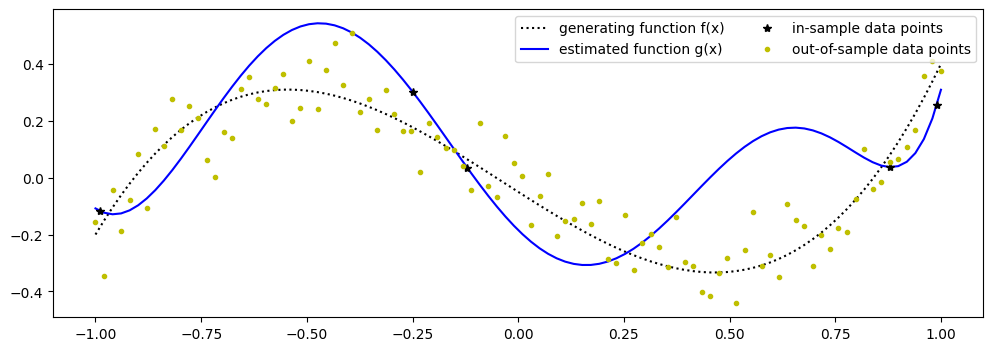

In [19]:
# Excercise #1: perform a baseline linear regression by using all predictors (p0, p1, ... p7) in the dataset

allvars = [x for x in data[0].columns if 'p' in x]
model_baseline = do_regression(data,allvars,verbose=True,plot=True)

In [7]:
# How results in exercise #1 compare to the ones presented in class? Does the model overfits the data? Why?
# It has the same result to the ones presented in class. The model overfits the data because:
# 1. In-sample Error is nearly zero
# 2. Out-Of_sample error is higher tham in-sample error
# 3. 0.14 R2, low R2 indicates poor generalization, the model is memorizing the data.

## PART 1: Subset Selection Methods

In [ ]:
# Exercise #2: implement a loop for computing linear regressions on all possible combinations of predictors,
# group the models according to the number of predictors used and generate a tabular representation showing
# only the model in each group exhibiting the smalest out-of-sample error. Include the following five fields
# in the table: model description (i.e. specific predictors used in the model), number of predictors, in-sample 
# error, out-of-sample error, out-of-sample R2 score.
p1_result = []
for k in range(2, len(data[0].columns)):
    all_vars = [x for x in data[0].columns if 'p' in x]
    combos = combinations(all_vars, k)
    for combo in combos:
        k_model_baseline = do_regression(data,list(combo),verbose=False,plot=False)
        p1_result.append({
            "model_description": f"model {k_model_baseline['type']} X{list(combo)}",
            "num_predictors": k,
            "in_sample_error": k_model_baseline['in_error'],
            "out_sample_error": k_model_baseline['out_error'],
            "out_sample_r2": k_model_baseline['out_r2']
        })



TypeError: Value after * must be an iterable, not int

In [ ]:
p1_results_df = pd.DataFrame(p1_result)
# Select best model per group (smallest out-of-sample error)
best_models = p1_results_df.loc[p1_results_df.groupby("num_predictors")["out_sample_error"].idxmin()]
print('Best Model is =')
display(best_models)

,model_description,num_predictors,in_sample_error,out_sample_error,out_sample_r2
8,"model linear X['p1', 'p3']",2,5.613881e-03,0.009612,0.825110
56,"model linear X['p1', 'p3', 'p6']",3,3.927155e-03,0.009329,0.830254
130,"model linear X['p1', 'p3', 'p4', 'p6']",4,3.793522e-03,0.009300,0.830774
199,"model linear X['p1', 'p3', 'p4', 'p5', 'p6']",5,4.068527e-32,0.032965,0.400177
231,"model linear X['p1', 'p2', 'p3', 'p4', 'p5', '...",6,3.352081e-32,0.034683,0.368916
245,"model linear X['p1', 'p2', 'p3', 'p4', 'p5', '...",7,9.126019e-32,0.037068,0.325517
246,"model linear X['p0', 'p1', 'p2', 'p3', 'p4', '...",8,1.703485e-32,0.046866,0.147242


In [ ]:
# Based in your results from exercise #2, what is the best model?
# <write your comments here>

In [ ]:
# Exercise #2 (continuation): perform a linear regression by using the optimal set of predictors encountered

# add your code here...


In [ ]:
# How results in exercise #2 compare to the ones presented in exercise #1? Does the model overfits the data?
# <write your comments here>

In [ ]:
# Exercise #3: implement a loop for computing linear regressions on transformed sets of predictors {zm}.
# More sepecifically, consider the sets {z1}, {z1,z2}, ... {z1,z2,...z7}. Use PCA for deriving the
# transformed predictos {zm} from the subset of original predictors {p1,p2,...p7} (i.e. exclude P0).
# Present the resuts in a similar tabular form as it was done in exercise #2.
# Suggestion: use all data avaiable (in-sample and out-of-sample) to learn the PCA projections!

# add your code here...


In [ ]:
# Based in your results from exercise #3, what is the best model?
# <write your comments here>

In [ ]:
# Exercise #3 (continuation): perform a linear regression by using the optimal set of transformed predictors

# add your code here...


In [ ]:
# How results in exercise #3 compare to the ones presented in exercises #1 and #2? Does the model overfits the data?
# <write your comments here>

## PART 2: Regularization Methods

In [ ]:
# Exercise #4: implement a loop to evaluate the performance of ridge regression along different values
# of the shrinkage factor alpha (lambda as used in class!). Generate plots for both the in-sample and 
# the out-of-sample errors vs the shrinkage factor value. Use the suggested value list!

# Suggested values for the shrinkage factor
lambdas = [k/100 for k in range(50)]

# add your code here...


In [ ]:
# How results in exercise #4 compare to the ones presented in class? What lambda value is providing best results?
# <write your comments here>

In [ ]:
# Exercise #4 (continuation): generate a plot showing all eight regression coefficients vs the shrinkage factor 

# add your code here...


In [ ]:
# What would be your main observations from the plot? How your results compare to the ones presented in class?
# <write your comments here>

In [ ]:
# Exercise #4 (continuation): perform a ridge regression by using the optimal shrinkage factor found

# add your code here...


In [ ]:
# How results in exercise #4 compare to the ones in exercises #1, #2 and #3? What are your main conclusions?
# <write your comments here>

In [ ]:
# Exercise #5: implement a loop to evaluate the performance of lasso regression along different values
# of the shrinkage factor alpha (lambda as used in class!). Generate plots for both the in-sample and 
# the out-of-sample errors vs the shrinkage factor value. Use the suggested value list!

# Suggested values for the shrinkage factor
lambdas = [k/1000 for k in range(50)]

# add your code here...


In [ ]:
# How results in exercise #5 compare to the ones presented in class? What lambda value is providing best results?
# <write your comments here>

In [ ]:
# Exercise #5 (continuation): generate a plot showing all eight regression coefficients vs the shrinkage factor 

# add your code here...


In [ ]:
# What would be your main observations from the plot? How your results compare to the ones presented in class?
# <write your comments here>

In [ ]:
# Exercise #5 (continuation): perform a lasso regression by using the optimal shrinkage factor found

# add your code here...


In [ ]:
# How results in exercise #5 compare to the ones in exercises #1, #2, #3 and #4? What are your main conclusions?
# <write your comments here>

In [ ]:
# Exercise #6: generate two bar plots (one for in-sample error and the other for out-of-sample error)
# comparing the models derived in exercises #1, #2, #3, #4, and #5

# add your code here...


In [ ]:
# What are your main conclusions from exercise #6 results?
# <write your comments here>

## PART 3: Applying Cross-validation

In [ ]:
# Consider the diabetes dataset provided within scikit learn
from sklearn.datasets import load_diabetes
data = load_diabetes()
print(data.DESCR)

In [ ]:
# Let us push predictors and target into a dataframe and perform a zero-mean untiary-variance normalization
datamtx = np.concatenate((data.data,data.target.reshape(-1,1)),axis=1)
datafrm = pd.DataFrame(data=datamtx,columns=data.feature_names+['targets'])
datafrm = (datafrm-datafrm.mean())/datafrm.std()
datafrm.head()

In [ ]:
# Exercise 7: here we use the RidgeCV class in scikit learn, which performs leave-one-out cross-validation
# and uses the optimal shrinkage factor to train a Ridge Regression model. You should read the corresponding 
# documentation in: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html, and
# get familiar with RidgeCV. Then, conduct the following steps:
# 1.- select a random sample of 30 data points as in-sample data
# 2.- select a random sample of 300 data points as out-of-sample data
# 3.- conduct a standard linear regression (use the fit method in LinearRegression)
# 3.a.- compute the in-sample coefficient of determination R2 (use the score method)
# 3.b.- compute the out-sample coefficient of determination R2 (use the score method)
# 4.- conduct a ridge regression with leave-one-out cross-validation (use the fit method in RidgeCV)
# 4.a.- consider the follwing values for the shrinkage factor [x/50 for x in range(1,5000)]
# 4.b.- make sure the resulting shrinkage factor is inside the provided range (otherwise ingnore the result)
# 4.c.- compute the in-sample coefficient of determination R2 (use the score method)
# 4.d.- compute the out-sample coefficient of determination R2 (use the score method)
# 5.- repeat steps 1 to 4 a significant number of times (~100)
# 6.- report means and standard deviations for the in-sample and out-of-sampe R2s in both regressions

from sklearn.linear_model import RidgeCV
lambdas = [x/50 for x in range(1,5000)]

# add your code here...


In [ ]:
# What are your main observations from exercise #7 results? Are you observing overfitting? Does Ridge help?
# <write your comments here>

In [ ]:
# Exercise 8: reuse your code from exercise #7 and implement a loop for comparing baseline and Ridge regression
# performances for different in-sample data sizes. Again, report means and standard deviations for the in-sample 
# and out-of-sampe R2s in both, baseline and Ridge, regressions. 

from sklearn.linear_model import RidgeCV
lambdas = [x/50 for x in range(1,5000)]
in_sample_sizes = [20,30,40,50,60,70,80,90,100]

# add your code here...


In [ ]:
# What are your main observations from exercise #8 results?
# <write your comments here>

In [ ]:
# Exercise #8 (continuation): produce a plot ilustrating the behavior of mean in-sample and out-of-sample 
# coefficient of determination R2 vs in-sample data size for both, baseline and Ridge, regressions. 

# add your code here...


In [ ]:
# What are your main observations from exercise #8 results? Where are you observing overfitting? Does Ridge help?
# <write your comments here>